<a href="https://colab.research.google.com/github/omarramos-droid/Tesis_CIMAT/blob/main/SIR_STANV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalar cmdstanpy y otras dependencias (ejecutar solo una vez)
!pip install cmdstanpy -q

import numpy as np
import matplotlib.pyplot as plt
import cmdstanpy
cmdstanpy.install_cmdstan()
from scipy.stats import lognorm, beta as beta_dist, gamma as gamma_dist
from statsmodels.graphics.tsaplots import plot_acf
import os

%matplotlib inline

CmdStan install directory: /root/.cmdstan
Installing CmdStan version: 2.38.0
Download successful, file: /tmp/tmps_stgym8
Extracting distribution
Unpacked download as cmdstan-2.38.0
Building version cmdstan-2.38.0, may take several minutes, depending on your system.
Installed cmdstan-2.38.0
Test model compilation


In [ ]:
# Código del solver fraccionario
import numpy as np
from math import gamma

_cache_potencias = {}

def precalcular_potencias(alpha, n_max):
    """Precalcula k^alpha y k^(alpha+1) para k=0..n_max+1."""
    key = (alpha, n_max)
    if key not in _cache_potencias:
        pow_alpha = np.zeros(n_max + 2)
        pow_alpha_plus1 = np.zeros(n_max + 2)
        for k in range(1, n_max + 2):
            pow_alpha[k] = k ** alpha
            pow_alpha_plus1[k] = k ** (alpha + 1)
        _cache_potencias[key] = (pow_alpha, pow_alpha_plus1)
    return _cache_potencias[key]

def proyectar_positivo(y, N_total):
    """Proyecta a valores >= 0 conservando N total."""
    y_proj = np.maximum(y, 0.0)
    total = np.sum(y_proj)
    if total > 1e-12:
        y_proj = y_proj * (N_total / total)
    else:
        y_proj = np.array([N_total, 0.0, 0.0])
    return y_proj

def resolver_fraccionario(funcion_rhs, alpha, y0, T, h, t_observacion=None):
    """Resuelve sistema fraccionario con Diethelm predictor-corrector."""
    N_pasos = int(round(T / h))
    t_fino = np.linspace(0, T, N_pasos + 1)
    dim = len(y0)
    N_total = np.sum(y0)

    gamma1 = gamma(alpha + 1)
    gamma2 = gamma(alpha + 2)
    h_alpha = h ** alpha

    pow_alpha, pow_alpha_plus1 = precalcular_potencias(alpha, N_pasos + 2)

    y = np.zeros((N_pasos + 1, dim))
    f_vals = np.zeros((N_pasos + 1, dim))

    y[0] = y0
    f_vals[0] = funcion_rhs(0.0, y[0])

    for n in range(1, N_pasos + 1):
        # Predictor
        b_coeffs = np.array([pow_alpha[n - j] - pow_alpha[n - j - 1]
                            for j in range(n)])
        y_pred = y[0] + (h_alpha / gamma1) * np.dot(b_coeffs, f_vals[:n])
        y_pred = proyectar_positivo(y_pred, N_total)
        f_pred = funcion_rhs(t_fino[n], y_pred)

        # Corrector
        a_coeffs = np.zeros(n + 1)
        if n >= 1:
            a_coeffs[0] = pow_alpha_plus1[n-1] - (n - 1 - alpha) * pow_alpha[n]
        for j in range(1, n):
            a_coeffs[j] = (pow_alpha_plus1[n - j + 1] +
                          pow_alpha_plus1[n - j - 1] -
                          2 * pow_alpha_plus1[n - j])
        a_coeffs[n] = 1.0

        y_corr = y[0] + (h_alpha / gamma2) * (
            np.dot(a_coeffs[:n], f_vals[:n]) + a_coeffs[n] * f_pred)
        y[n] = proyectar_positivo(y_corr, N_total)
        f_vals[n] = funcion_rhs(t_fino[n], y[n])

    resultado = {'t_fino': t_fino, 'y_fino': y}

    if t_observacion is not None:
        indices = np.clip(np.round(t_observacion / h).astype(int), 0, N_pasos)
        resultado['y_obs'] = y[indices]
        resultado['t_obs'] = t_observacion

    return resultado

def sir_rhs(t, y, beta, gamma, N):
    """Lado derecho del modelo SIR."""
    S, I, R = y
    return np.array([-beta * S * I / N,
                      beta * S * I / N - gamma * I,
                      gamma * I])

def resolver_sir(beta, gamma, N, I0, alpha, T, h, t_observacion=None):
    """Función de conveniencia para resolver SIR fraccionario."""
    y0 = np.array([N - I0, I0, 0.0])
    return resolver_fraccionario(
        lambda t, y: sir_rhs(t, y, beta, gamma, N),
        alpha, y0, T, h, t_observacion
    )

In [ ]:
SIR_STAN = """
functions {
  vector sir_rhs(real t, vector Y, real beta, real gamma, real N) {
    vector[3] dY;
    real S = Y[1];
    real I = Y[2];
    dY[1] = -beta * S * I / N;
    dY[2] =  beta * S * I / N - gamma * I;
    dY[3] =  gamma * I;
    return dY;
  }

  matrix solver_sir(real alpha, real beta, real gamma, real N, real I0,
                    int T, real h) {
    real gamma_a1 = tgamma(alpha + 1);
    real gamma_a2 = tgamma(alpha + 2);
    real h_alpha   = pow(h, alpha);

    matrix[T+1,3] y;
    array[T+1] vector[3] f_vals;

    // condiciones iniciales
    y[1,1] = N - I0;
    y[1,2] = I0;
    y[1,3] = 0;
    f_vals[1] = sir_rhs(0, to_vector(y[1,]), beta, gamma, N);

    for (n in 2:(T+1)) {
      vector[3] sum_pred = rep_vector(0.0, 3);
      vector[3] sum_corr = rep_vector(0.0, 3);

      // Predictor
      for (j in 1:(n-1)) {
        real b_j = (n - j)^alpha - (n - j - 1)^alpha;
        sum_pred += b_j * f_vals[j];
      }
      vector[3] y_pred = to_vector(y[1,]) + (h_alpha / gamma_a1) * sum_pred;

      // Proyección de positividad
      {
        real total = y_pred[1] + y_pred[2] + y_pred[3];
        for (k in 1:3) y_pred[k] = fmax(y_pred[k], 0.0);
        total = fmax(total, 1e-12);
        y_pred = y_pred * (N / total);
      }
      vector[3] f_pred = sir_rhs((n-1)*h, y_pred, beta, gamma, N);

      // Corrector
      real a0 = (n-2)^(alpha+1) - (n-2 - alpha)*(n-1)^alpha;
      sum_corr = a0 * f_vals[1];
      for (j in 2:(n-1)) {
        real a_j = (n - j + 1)^(alpha+1)
                 - 2*(n - j)^(alpha+1)
                 + (n - j - 1)^(alpha+1);
        sum_corr += a_j * f_vals[j];
      }
      vector[3] y_corr = to_vector(y[1,]) + (h_alpha / gamma_a2) * (sum_corr + f_pred);

      // Proyección de positividad (Mantiene cte la poblacion)
      {
        real total = y_corr[1] + y_corr[2] + y_corr[3];
        for (k in 1:3) y_corr[k] = fmax(y_corr[k], 0.0);
        total = fmax(total, 1e-12);
        y_corr = y_corr * (N / total);
      }
      y[n] = y_corr';
      f_vals[n] = sir_rhs((n-1)*h, y_corr, beta, gamma, N);
    }
    return y;
  }
}

data {
  int<lower=1> n_obs;
  array[n_obs] int<lower=0> y;
  real<lower=0> N;
  real<lower=0> h;
  int<lower=1> T;
}

parameters {
  real<lower=0>     beta;
  real<lower=0>     gamma;
  real<lower=1>     I0;
  real<lower=0.2, upper=1> alpha;
  real<lower=0.01>  phi;
}

transformed parameters {
  matrix[T+1,3] sol = solver_sir(alpha, beta, gamma, N, I0, T, h);

  array[T] real incidence;
  for (t in 1:T) {
    real diff = sol[t,1] - sol[t+1,1];
    if (diff <= 0)
      incidence[t] = 1e-6;
    else
      incidence[t] = diff;
  }
}

model {
  // Priors
  beta  ~ lognormal(-0.5, 0.5);
  gamma ~ lognormal(-0.5, 0.5);
  I0    ~ gamma(2, 0.5);
  alpha ~ beta(2,2);
  phi   ~ gamma(2, 0.1);

  // Likelihood
  for (t in 1:T)
    y[t] ~ neg_binomial_2(incidence[t], phi);
}

generated quantities {
  real R0 = beta / gamma;
  array[T] int y_rep;
  for (t in 1:T)
    y_rep[t] = neg_binomial_2_rng(incidence[t], phi);
}
"""

In [ ]:
# Datos observados
y_obs = np.array([18, 59, 150, 274, 493, 619, 606, 520, 253, 114, 74, 77,
                  26, 11, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
N_total = 4500
h = 1.0                     # paso diario
T = len(y_obs)

stan_data = {
    'n_obs': T,
    'y': y_obs.tolist(),
    'N': N_total,
    'h': h,
    'T': T
}

# Guardar modelo Stan en un archivo temporal
with open("SIR_model.stan", "w") as f:
    f.write(SIR_STAN)

# Compilar
model = cmdstanpy.CmdStanModel(stan_file="SIR_model.stan")

# Muestrear
fit = model.sample(
    data=stan_data,
    chains=2,
    parallel_chains=2,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=13
)

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

	Chain 1 had 7 divergent transitions (0.7%)
	Chain 2 had 1 divergent transitions (0.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [ ]:
NOMBRES = ['beta', 'gamma', 'alpha', 'phi', 'I0']

def extraer_posterior_combinado(fit, nombres=NOMBRES):
    """
    Obtiene todas las muestras (todas las cadenas) usando stan_variables.
    """
    sv = fit.stan_variables()          # dict: clave -> array 1D (n_total)
    return np.column_stack([sv[var] for var in nombres])

def extraer_posterior_por_cadena(fit, nombres=NOMBRES):
    """
    Devuelve una lista de arrays, uno por cada cadena.
    """
    df = fit.draws_pd(vars=nombres)

    # fit.chains es el número de cadenas (int)
    n_chains = fit.chains
    n_draws_total = len(df)
    n_draws_per_chain = n_draws_total // n_chains

    # Construir un índice multinivel: (chain, draw)
    cadenas_idx = np.repeat(np.arange(1, n_chains + 1), n_draws_per_chain)
    draws_idx   = np.tile(np.arange(1, n_draws_per_chain + 1), n_chains)
    df.index = pd.MultiIndex.from_arrays(
        [cadenas_idx, draws_idx], names=['chain', 'draw']
    )

    cadenas = []
    for c in range(1, n_chains + 1):
        sub_df = df.xs(c, level='chain')
        cadenas.append(sub_df.to_numpy())
    return cadenas

def graficar_trazas(cadenas):
    n_param = len(NOMBRES)
    fig, axes = plt.subplots(n_param, 1, figsize=(12, 3*n_param), sharex=True)
    if n_param == 1: axes = [axes]
    colores = ['#1f77b4', '#ff7f0e']
    for i, ax in enumerate(axes):
        for j, cad in enumerate(cadenas):
            ax.plot(cad[:, i], alpha=0.7, lw=0.5, color=colores[j % 2],
                    label=f'Cadena {j+1}')
        ax.set_ylabel(NOMBRES[i])
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel('Iteración')
    plt.suptitle('Trazas de las cadenas', fontsize=14)
    plt.tight_layout()
    plt.show()

def graficar_dispersiones(posterior):
    n = len(NOMBRES)
    fig, axes = plt.subplots(n, n, figsize=(12, 12))
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if i == j:
                ax.hist(posterior[:, i], bins=40, color='gray', alpha=0.7)
            else:
                ax.scatter(posterior[:, j], posterior[:, i],
                           alpha=0.3, s=5, color='blue', edgecolors='none')
            if i == n-1:
                ax.set_xlabel(NOMBRES[j])
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(NOMBRES[i])
            else:
                ax.set_yticklabels([])
    plt.suptitle('Matriz de dispersión', fontsize=14)
    plt.tight_layout()
    plt.show()

def graficar_autocorrelacion(posterior, lags=50):
    n_param = len(NOMBRES)
    fig, axes = plt.subplots(n_param, 1, figsize=(10, 3*n_param))
    if n_param == 1: axes = [axes]
    for i, ax in enumerate(axes):
        plot_acf(posterior[:, i], lags=lags, ax=ax, title=f'Autocorrelación {NOMBRES[i]}')
    plt.tight_layout()
    plt.show()

def graficar_ajuste_incidencia(fit, y_obs, t_obs, N_total, h_solver=0.01, nsamples=40):
    posterior = extraer_posterior_combinado(fit)
    idx = np.random.choice(posterior.shape[0], size=nsamples, replace=False)
    dias = t_obs[1:]
    plt.figure(figsize=(12, 6))
    for ind in idx:
        beta, gamma, alpha, phi, I0 = posterior[ind, :]
        try:
            res = resolver_sir(beta=beta, gamma=gamma, N=N_total, I0=float(I0),
                               alpha=alpha, T=t_obs[-1], h=h_solver,
                               t_observacion=t_obs)
            S_obs = res['y_obs'][:, 0]
            inc = np.maximum(S_obs[:-1] - S_obs[1:], 1e-8)
            plt.plot(dias, inc, color='blue', alpha=0.15, linewidth=0.8)
        except:
            continue
    # Curva media
    theta_media = np.mean(posterior, axis=0)
    try:
        res_media = resolver_sir(beta=theta_media[0], gamma=theta_media[1],
                                 N=N_total, I0=float(theta_media[4]),
                                 alpha=theta_media[2], T=t_obs[-1], h=h_solver,
                                 t_observacion=t_obs)
        S_media = res_media['y_obs'][:, 0]
        inc_media = np.maximum(S_media[:-1] - S_media[1:], 1e-8)
        plt.plot(dias, inc_media, 'r-', linewidth=2.5, label='Media posterior')
    except:
        pass
    plt.scatter(dias, y_obs, color='black', s=20, label='Datos observados', zorder=5)
    plt.xlabel('Día')
    plt.ylabel('Casos nuevos')
    plt.title(f'Ajuste – {nsamples} curvas posteriores')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def resumen_numerico(posterior):
    res = {}
    for i, nom in enumerate(NOMBRES):
        vals = posterior[:, i]
        res[nom] = {
            'media': np.mean(vals),
            'mediana': np.median(vals),
            'ic_inf_95': np.percentile(vals, 2.5),
            'ic_sup_95': np.percentile(vals, 97.5)
        }
    R0_vals = posterior[:, 0] / posterior[:, 1]
    res['R0'] = {
        'media': np.mean(R0_vals),
        'mediana': np.median(R0_vals),
        'ic_inf_95': np.percentile(R0_vals, 2.5),
        'ic_sup_95': np.percentile(R0_vals, 97.5)
    }
    return res




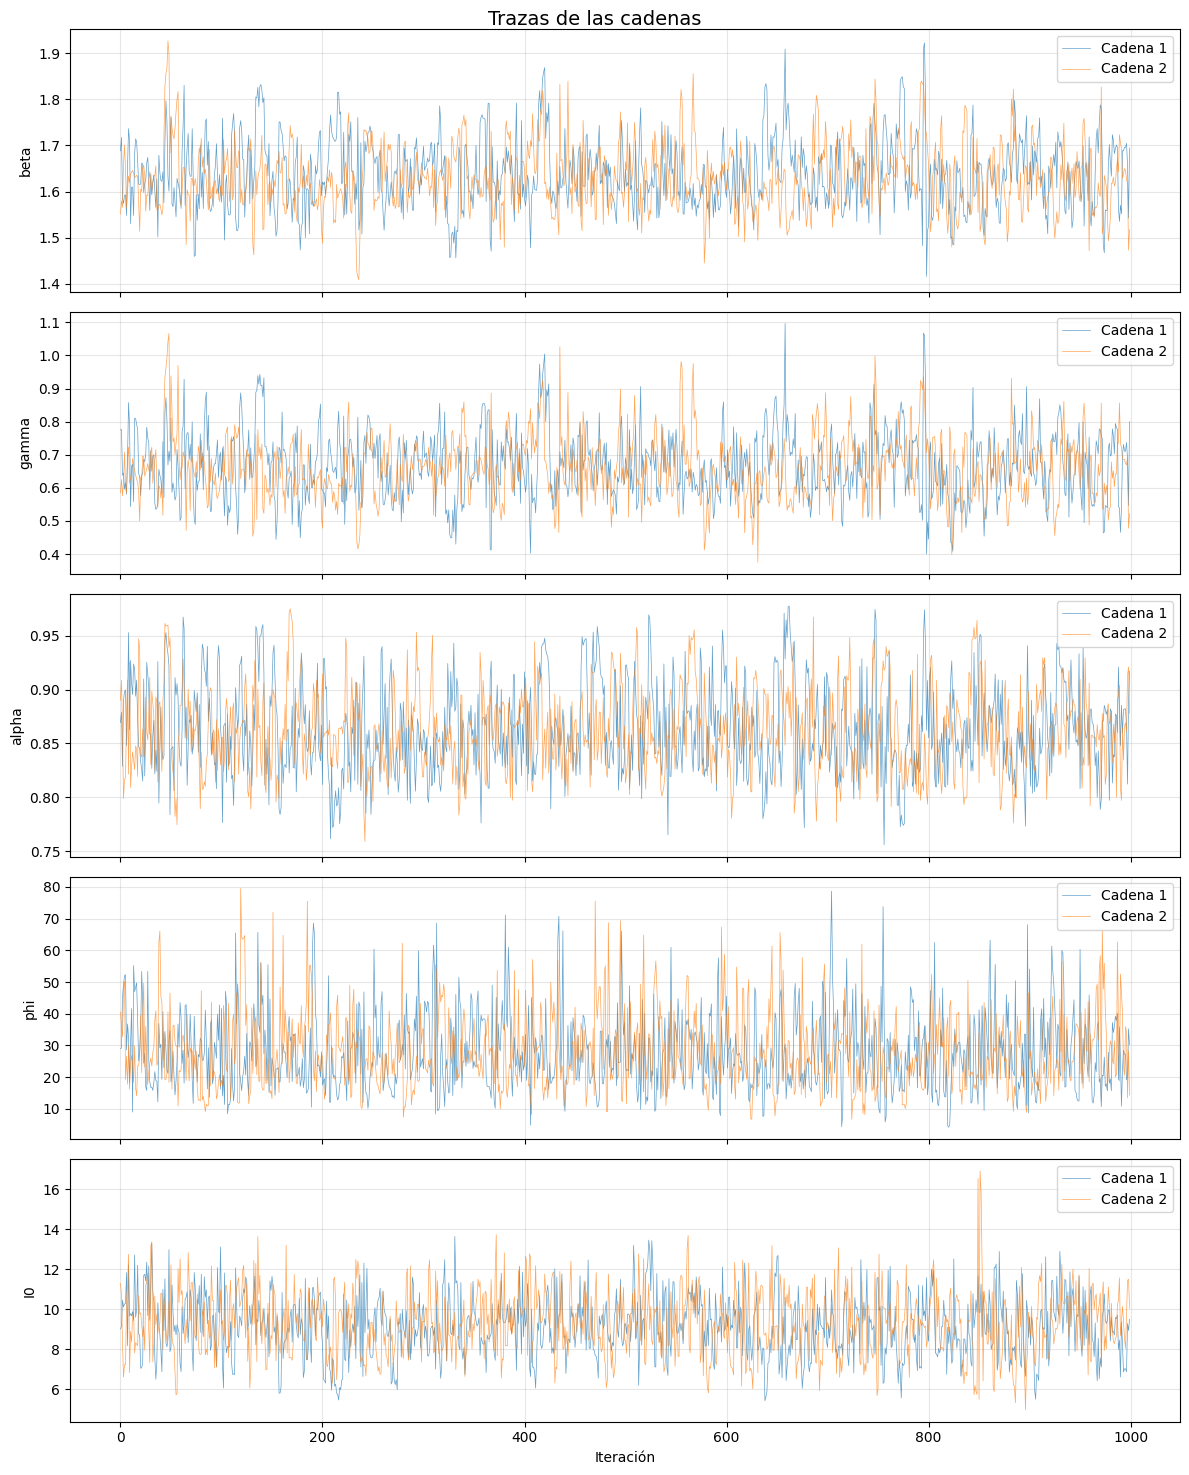

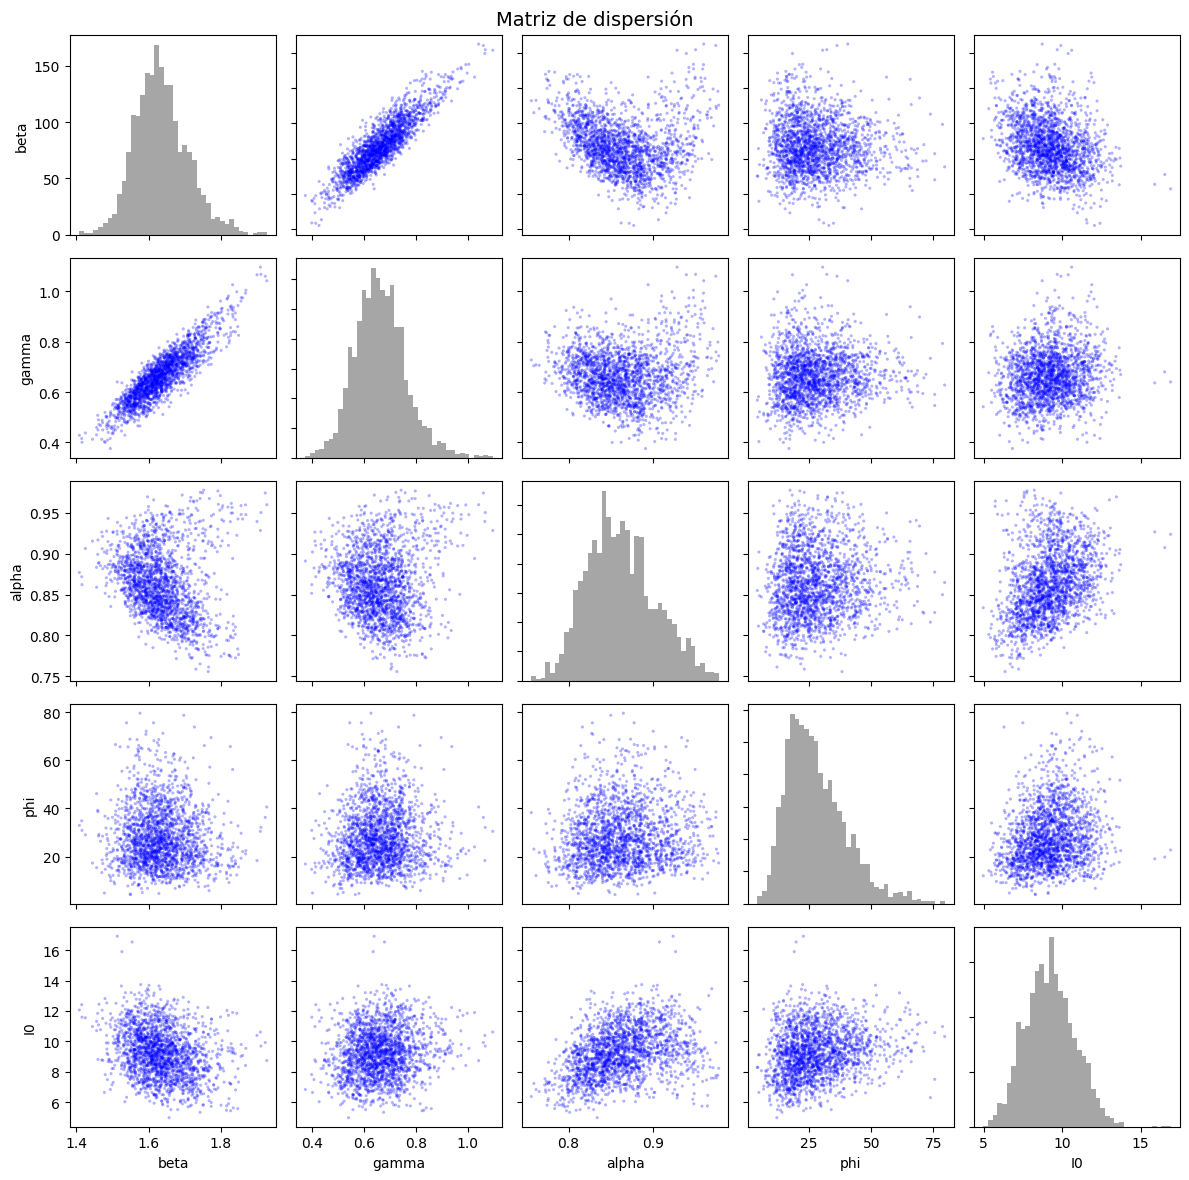

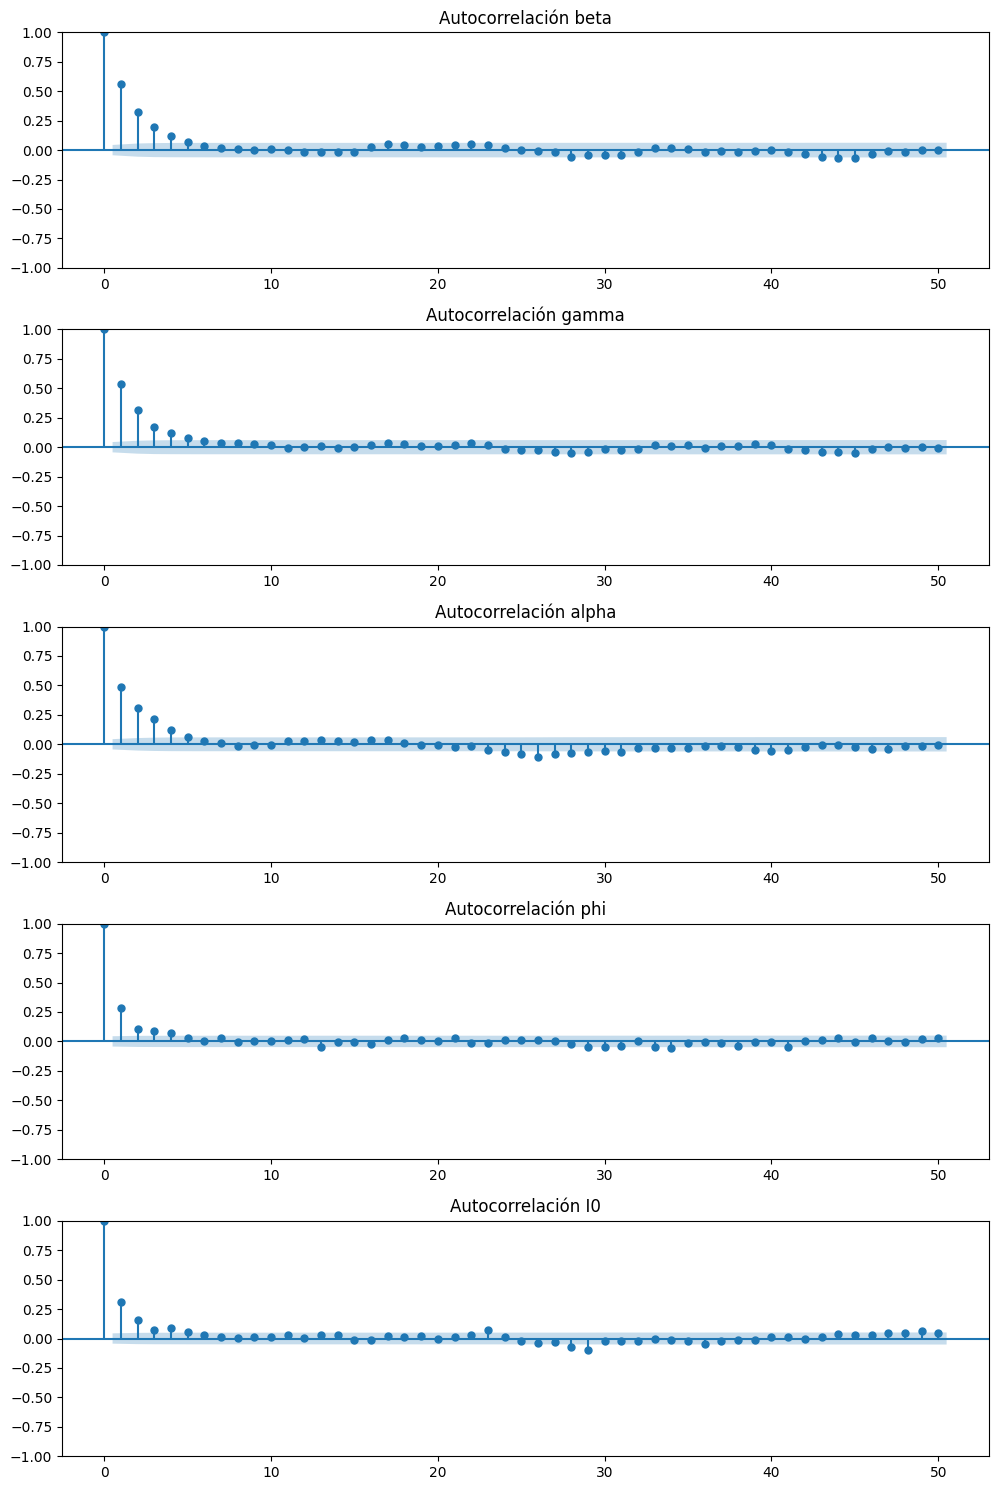

Resumen posterior:
beta  : media=1.6349, 95% CI=(1.5079, 1.7979)
gamma : media=0.6636, 95% CI=(0.4877, 0.8870)
alpha : media=0.8625, 95% CI=(0.7938, 0.9480)
phi   : media=28.0090, 95% CI=(10.7172, 57.6242)
I0    : media=9.2363, 95% CI=(6.3157, 12.3266)
R0    : media=2.5042, 95% CI=(2.0041, 3.1440)


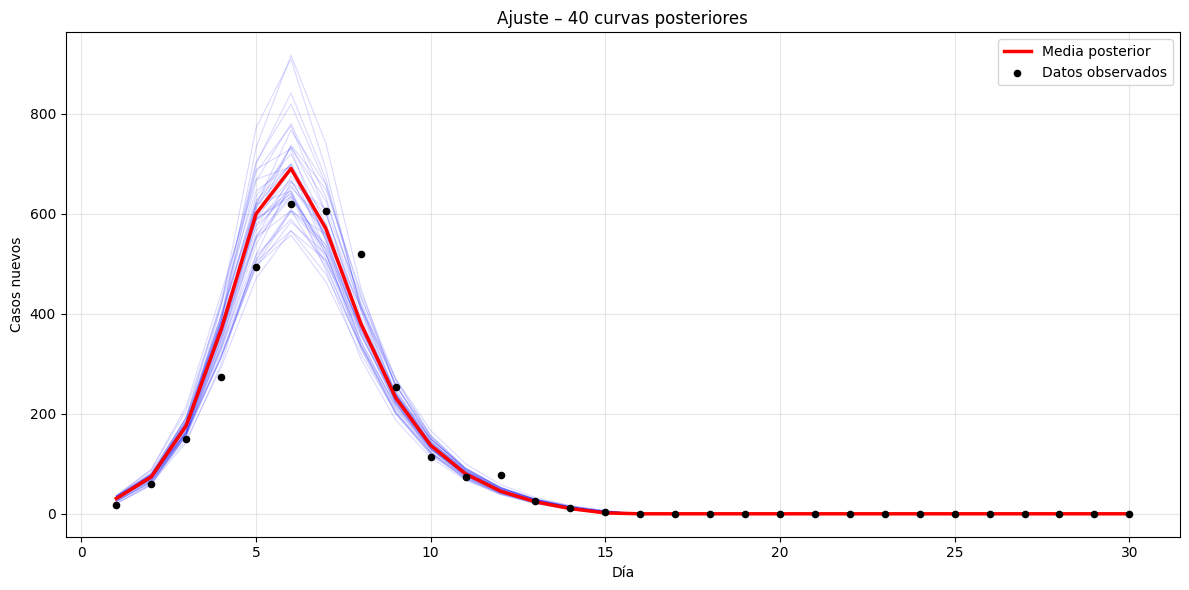

In [ ]:
import pandas as pd
posterior = extraer_posterior_combinado(fit)
cadenas = extraer_posterior_por_cadena(fit)

# Gráficos principales
graficar_trazas(cadenas)
graficar_dispersiones(posterior)
graficar_autocorrelacion(posterior, lags=50)
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Posterior samples
beta_post = fit.stan_variable('beta')
gamma_post = fit.stan_variable('gamma')
I0_post = fit.stan_variable('I0')
phi_post = fit.stan_variable('phi')
alpha_post= fit.stan_variable('alpha')
np.random.seed(123)
n = len(beta_post)

# PRIORS EXACTAS DEL MODELO STAN
beta_prior = np.random.lognormal(mean=-1, sigma=1, size=n)
gamma_prior = np.random.lognormal(mean=-2, sigma=1, size=n)
I0_prior = np.random.lognormal(mean=2, sigma=1, size=n)
alpha_prior= np.random.beta(2,2, size=n)
phi_inv_prior = np.random.exponential(scale=1, size=n)
phi_prior = 1 / phi_inv_prior


fig, ax = plt.subplots(2,2, figsize=(14,10))

# BETA
x = np.linspace(0,3,300)
ax[0,0].hist(beta_post, bins=60, density=True, alpha=0.6,label="Posterior")
ax[0,0].plot(x, stats.lognorm.pdf(x,1,scale=np.exp(-1)),lw=2,label="Prior")
ax[0,0].set_title("β")
ax[0,0].legend()

# GAMMA
x = np.linspace(0,1,300)
ax[0,1].hist(gamma_post, bins=60, density=True, alpha=0.6,label="Posterior")
ax[0,1].plot(x, stats.lognorm.pdf(x,1,scale=np.exp(-2)),lw=2,label="Prior")
ax[0,1].set_title("γ")
ax[0,1].legend()

# I0
x = np.linspace(0,200,300)
ax[1,0].hist(I0_post, bins=60, density=True, alpha=0.6,label="Posterior")
ax[1,0].plot(x, stats.lognorm.pdf(x,1,scale=np.exp(2)),lw=2,label="Prior")
ax[1,0].set_title("I0")
ax[1,0].legend()

# ALPHA
x = np.linspace(0,1,300)
ax[1,1].hist(alpha_post, bins=60, density=True, alpha=0.6,label="Posterior")
ax[1,1].plot(x, stats.beta.pdf(x,2,2),lw=2,label="Prior")
ax[1,1].set_title("alpha")
ax[1,1].legend()

plt.tight_layout()
plt.show()

# Resumen numérico
res = resumen_numerico(posterior)
print("Resumen posterior:")
for par, stats in res.items():
    print(f"{par:6s}: media={stats['media']:.4f}, 95% CI=({stats['ic_inf_95']:.4f}, {stats['ic_sup_95']:.4f})")

# Ajuste predictivo
t_obs = np.arange(0, len(y_obs)+1)
graficar_ajuste_incidencia(fit, y_obs, t_obs, N_total=4500, h_solver=0.01, nsamples=40)